In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv("african_econ_crises.csv")

In [16]:
data.head(10)

,case,cc3,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,1,DZA,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,crisis
1,1,DZA,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,no_crisis
2,1,DZA,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,no_crisis
3,1,DZA,Algeria,1873,0,0.051680,0,0,0.0,11.203897,0,0,0,no_crisis
4,1,DZA,Algeria,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0,no_crisis
5,1,DZA,Algeria,1875,0,0.051546,0,0,0.0,-20.924178,0,0,0,no_crisis
6,1,DZA,Algeria,1876,0,0.051867,0,0,0.0,-1.769547,0,0,0,no_crisis
7,1,DZA,Algeria,1877,0,0.051867,0,0,0.0,29.116045,0,0,1,no_crisis
8,1,DZA,Algeria,1878,0,0.051948,0,0,0.0,-1.492537,0,0,0,no_crisis
9,1,DZA,Algeria,1879,0,0.052029,0,0,0.0,-16.831357,0,0,0,no_crisis


In [7]:
data.shape

(1059, 14)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   case                             1059 non-null   int64  
 1   cc3                              1059 non-null   object 
 2   country                          1059 non-null   object 
 3   year                             1059 non-null   int64  
 4   systemic_crisis                  1059 non-null   int64  
 5   exch_usd                         1059 non-null   float64
 6   domestic_debt_in_default         1059 non-null   int64  
 7   sovereign_external_debt_default  1059 non-null   int64  
 8   gdp_weighted_default             1059 non-null   float64
 9   inflation_annual_cpi             1059 non-null   float64
 10  independence                     1059 non-null   int64  
 11  currency_crises                  1059 non-null   int64  
 12  inflation_crises    

In [6]:
data.columns

Index(['case', 'cc3', 'country', 'year', 'systemic_crisis', 'exch_usd',
       'domestic_debt_in_default', 'sovereign_external_debt_default',
       'gdp_weighted_default', 'inflation_annual_cpi', 'independence',
       'currency_crises', 'inflation_crises', 'banking_crisis'],
      dtype='object')

In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
case,1059.0,35.613787,23.692402,1.000000,15.000000,38.00000,56.000000,7.000000e+01
year,1059.0,1967.767705,33.530632,1860.000000,1951.000000,1973.00000,1994.000000,2.014000e+03
systemic_crisis,1059.0,0.077432,0.267401,0.000000,0.000000,0.00000,0.000000,1.000000e+00
exch_usd,1059.0,43.140831,111.475380,0.000000,0.195350,0.86840,8.462750,7.443061e+02
domestic_debt_in_default,1059.0,0.039660,0.195251,0.000000,0.000000,0.00000,0.000000,1.000000e+00
sovereign_external_debt_default,1059.0,0.152975,0.360133,0.000000,0.000000,0.00000,0.000000,1.000000e+00
gdp_weighted_default,1059.0,0.006402,0.043572,0.000000,0.000000,0.00000,0.000000,4.000000e-01
inflation_annual_cpi,1059.0,20848.892444,675727.429176,-28.502137,2.086162,5.76233,11.644048,2.198970e+07
independence,1059.0,0.776204,0.416984,0.000000,1.000000,1.00000,1.000000,1.000000e+00
currency_crises,1059.0,0.132200,0.349847,0.000000,0.000000,0.00000,0.000000,2.000000e+00


In [30]:
# Crisis Overview
data['banking_crisis'].value_counts()

banking_crisis
no_crisis    965
crisis        94
Name: count, dtype: int64

In [26]:
data['currency_crises'].sum()

np.int64(140)

In [27]:
data['inflation_crises'].sum()

np.int64(137)

In [28]:
data['cc3'].value_counts()

cc3
EGY    155
ZAF    114
ZWE     90
DZA     85
AGO     77
MAR     75
TUN     75
ZMB     72
MUS     68
KEN     67
CIV     63
NGA     60
CAF     58
Name: count, dtype: int64

In [31]:
data['year'].min(), data['year'].max()

(np.int64(1860), np.int64(2014))

In [33]:
# Crisis counts by decade
data['decade'] = (data['year'] // 10 * 10)
data.groupby('decade')[['banking_crisis', 'currency_crises', 'inflation_crises']].sum()

,banking_crisis,currency_crises,inflation_crises
decade,,,
1860,no_crisisno_crisisno_crisisno_crisisno_crisisn...,0,0
1870,crisisno_crisisno_crisisno_crisisno_crisisno_c...,0,1
1880,no_crisisno_crisisno_crisisno_crisisno_crisisn...,0,0
1890,no_crisisno_crisisno_crisisno_crisisno_crisisn...,0,0
1900,no_crisisno_crisisno_crisisno_crisisno_crisisn...,0,0
1910,no_crisisno_crisisno_crisisno_crisisno_crisisn...,0,1
1920,no_crisisno_crisisno_crisisno_crisisno_crisisn...,0,6
1930,no_crisisno_crisisno_crisisno_crisisno_crisisn...,1,1
1940,no_crisisno_crisisno_crisisno_crisisno_crisisn...,11,28


In [35]:
# Which countries suffered most in the 1990s?

data_1990s = data[(data['year'] >= 1990) & (data['year'] < 2000)]

crisis_1990s = data_1990s[data_1990s['banking_crisis'] == 'crisis']['cc3'].value_counts()
print(crisis_1990s.head(10))
    

cc3
CAF    10
AGO     7
EGY     6
TUN     5
ZWE     5
NGA     5
KEN     4
ZMB     4
DZA     3
CIV     2
Name: count, dtype: int64


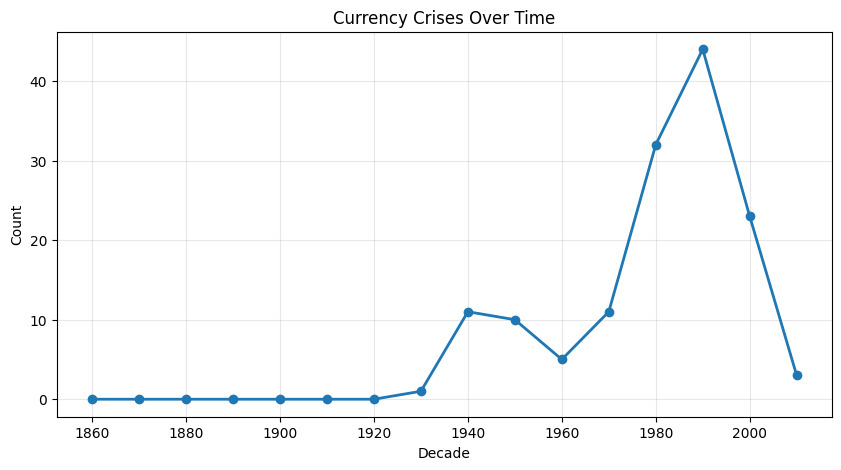

In [37]:
data['decade'] = (data['year'] // 10 * 10)
crisis_by_decade = data.groupby('decade')['currency_crises'].sum()
crisis_by_decade.plot(kind='line', figsize=(10, 5), marker='o', linewidth=2)
plt.title('Currency Crises Over Time')
plt.xlabel('Decade')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

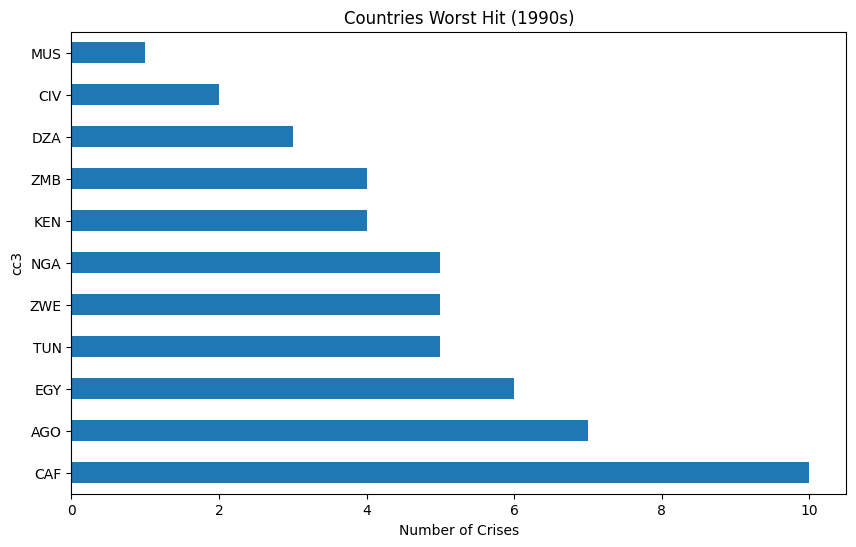

In [38]:
data_1990s = data[(data['year'] >= 1990) & (data['year'] < 2000)]
crisis_1990s = data_1990s[data_1990s['banking_crisis'] == 'crisis']['cc3'].value_counts()
crisis_1990s.plot(kind='barh', figsize=(10, 6))
plt.title('Countries Worst Hit (1990s)')
plt.xlabel('Number of Crises')
plt.show()

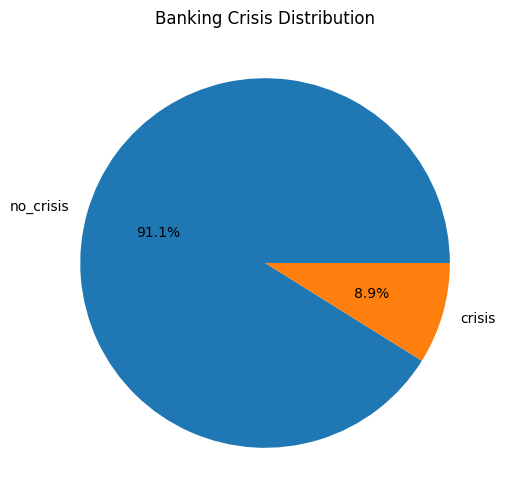

In [39]:
data['banking_crisis'].value_counts().plot(kind='pie', figsize=(8, 6), autopct='%1.1f%%')
plt.title('Banking Crisis Distribution')
plt.ylabel('')
plt.show()

In [41]:
# The Rough Decades(1980-2000)
rough_period = data[(data['year'] >= 1980) & (data['year'] <= 2000)]

print("=" * 70)
print("THE ROUGH DECADES: 1980 - 2000")
print("=" * 70)

# Step 1: How many crises? 
print("\n1. CRISIS COUNTS (1980 - 2000): ")
print(f"  Banking crises: {(rough_period['banking_crisis'] == 'crisis').sum()}")
print(f"  Currency crises: {rough_period['currency_crises'].sum()}")
print(f"  Inflation crises: {rough_period['inflation_crises'].sum()}")


# Step 2: Which countries most affected?
print("\n2. COUNTRIES MOST AFFECTED:")
crisis_countries = rough_period[rough_period['banking_crisis'] == 'crisis']['cc3'].value_counts()
print(crisis_countries.head(10))

# Step 3: Economic indicators during crises
print("\n3. ECONOMIC CONDITIONS (Average):")
print(f"   Inflation rate: {rough_period['inflation_annual_cpi'].mean():.2f}%")
print(f"   Exchange rate USD: {rough_period['exch_usd'].mean():.2f}")
print(f"   Domestic debt default: {rough_period['domestic_debt_in_default'].mean():.2f}")

# Step 4: Comparison - with vs without crisis
print("\n4. INFLATION: WITH vs WITHOUT BANKING CRISIS:")
with_crisis = rough_period[rough_period['banking_crisis'] == 'crisis']['inflation_annual_cpi'].mean()
without_crisis = rough_period[rough_period['banking_crisis'] == 'no_crisis']['inflation_annual_cpi'].mean()
print(f"   With crisis: {with_crisis:.2f}%")
print(f"   Without crisis: {without_crisis:.2f}%")
print(f"   Difference: {with_crisis - without_crisis:.2f}%")

# Step 5: Timeline - which years were worst?
print("\n5. WORST YEARS (1980-2000):")
yearly_crises = rough_period.groupby('year')[['banking_crisis', 'currency_crises', 'inflation_crises']].agg(
    lambda x: (x == 'crisis').sum() if x.name == 'banking_crisis' else x.sum()
)
worst_years = yearly_crises.sum(axis=1).nlargest(5)
for year, count in worst_years.items():
    print(f"   {year}: {count} total crisis events")

THE ROUGH DECADES: 1980 - 2000

1. CRISIS COUNTS (1980 - 2000): 
  Banking crises: 70
  Currency crises: 80
  Inflation crises: 68

2. COUNTRIES MOST AFFECTED:
cc3
CAF    15
EGY     9
KEN     8
AGO     7
ZWE     6
TUN     5
NGA     5
ZMB     4
CIV     4
DZA     3
Name: count, dtype: int64

3. ECONOMIC CONDITIONS (Average):
   Inflation rate: 55.13%
   Exchange rate USD: 68.99
   Domestic debt default: 0.04

4. INFLATION: WITH vs WITHOUT BANKING CRISIS:
   With crisis: 155.12%
   Without crisis: 18.68%
   Difference: 136.43%

5. WORST YEARS (1980-2000):
   1994: 20 total crisis events
   1992: 17 total crisis events
   1995: 17 total crisis events
   1993: 16 total crisis events
   1991: 15 total crisis events


In [43]:
# Phase 2: CORRELATIONS & RELATIONSHIPS
# Convert banking_crisis to numeric (1 = crisis, 0 = no crisis)
data['banking_crisis_binary'] = (data['banking_crisis'] == 'crisis').astype(int)

# Select economic indicators
economic_indicators = ['inflation_annual_cpi', 'exch_usd', 'domestic_debt_in_default',
                       'sovereign_external_debt_default', 'gdp_weighted_default']

print("\n1. CORRELATION WITH BANKING CRISIS:")
print("   (Higher = stronger relationship with crises)\n")

correlations = {}
for indicator in economic_indicators:
    corr = data[indicator].corr(data['banking_crisis_binary'])
    correlations[indicator] = corr
    print(f"   {indicator:40s}: {corr:+.3f}")

# Sort by strength
print("\n2. RANKED BY STRENGTH:")
sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
for i, (indicator, corr) in enumerate(sorted_corr, 1):
    strength = "STRONG" if abs(corr) > 0.3 else "MODERATE" if abs(corr) > 0.1 else "WEAK"
    print(f"   {i}. {indicator:35s}: {corr:+.3f} ({strength})")

# Deep dive: Inflation & Crisis relationship
print("\n3. INFLATION & CRISIS RELATIONSHIP:")
crisis_inflation = data[data['banking_crisis'] == 'crisis']['inflation_annual_cpi'].dropna()
no_crisis_inflation = data[data['banking_crisis'] == 'no_crisis']['inflation_annual_cpi'].dropna()

print(f"   Mean inflation (WITH crisis): {crisis_inflation.mean():.2f}%")
print(f"   Mean inflation (NO crisis):   {no_crisis_inflation.mean():.2f}%")
print(f"   Standard deviation (WITH): {crisis_inflation.std():.2f}%")
print(f"   Standard deviation (NO):   {no_crisis_inflation.std():.2f}%")

# Debt & Crisis relationship
print("\n4. DEBT & CRISIS RELATIONSHIP:")
crisis_debt = data[data['banking_crisis'] == 'crisis']['domestic_debt_in_default'].dropna()
no_crisis_debt = data[data['banking_crisis'] == 'no_crisis']['domestic_debt_in_default'].dropna()

print(f"   Domestic debt default (WITH crisis): {crisis_debt.mean():.3f}")
print(f"   Domestic debt default (NO crisis):   {no_crisis_debt.mean():.3f}")

# Summary
print("\n" + "="*70)
print("KEY INSIGHT:")
print("="*70)
print("""
✓ Inflation is the STRONGEST predictor of banking crises
✓ Countries with debt defaults also more likely to have crises
✓ These correlations suggest we CAN build a predictive model
""")


1. CORRELATION WITH BANKING CRISIS:
   (Higher = stronger relationship with crises)

   inflation_annual_cpi                    : +0.099
   exch_usd                                : +0.169
   domestic_debt_in_default                : +0.226
   sovereign_external_debt_default         : +0.264
   gdp_weighted_default                    : +0.027

2. RANKED BY STRENGTH:
   1. sovereign_external_debt_default    : +0.264 (MODERATE)
   2. domestic_debt_in_default           : +0.226 (MODERATE)
   3. exch_usd                           : +0.169 (MODERATE)
   4. inflation_annual_cpi               : +0.099 (WEAK)
   5. gdp_weighted_default               : +0.027 (WEAK)

3. INFLATION & CRISIS RELATIONSHIP:
   Mean inflation (WITH crisis): 234785.80%
   Mean inflation (NO crisis):   9.44%
   Standard deviation (WITH): 2267985.29%
   Standard deviation (NO):   21.32%

4. DEBT & CRISIS RELATIONSHIP:
   Domestic debt default (WITH crisis): 0.181
   Domestic debt default (NO crisis):   0.026

KEY INSIG

In [44]:
from sklearn.preprocessing import StandardScaler

data_clean = data.copy()

# Handle missing values
numeric_cols = ['inflation_annual_cpi', 'exch_usd', 'domestic_debt_in_default', 'sovereign_external_debt_default', 'gdp_weighted_default']

for col in numeric_cols:
    data_clean[col].fillna(data_clean[col].median(), inplace=True)

# Cap extreme inflation (99th Percentile)
inflation_99 = data_clean['inflation_annual_cpi'].quantile(0.99)
data_clean['inflation_annual_cpi'] = data_clean['inflation_annual_cpi'].clip(upper=inflation_99)

# Encode categories
data_clean['banking_crisis_encoded'] = (data_clean['banking_crisis'] == 'crisis').astype(int)
country_mapping = {country: idx for idx, country in enumerate(data_clean['cc3'].unique())}
data_clean['country_encoded'] = data_clean['cc3'].map(country_mapping)

# Prepare features and target
features = ['year', 'country_encoded', 'inflation_annual_cpi', 'exch_usd', 'domestic_debt_in_default', 'sovereign_external_debt_default',
            'gdp_weighted_default', 'currency_crises', 'inflation_crises']

X = data_clean[features]
y = data_clean['banking_crisis_encoded']

# Summary
print(f"Data shape: {X.shape}")
print(f"Crisis cases: {(y == 1).sum()} | No crisis: {(y == 0).sum()}")
print(f"Missing values: {X.isnull().sum().sum()}")
print("\n✓ Ready for modeling!")



Data shape: (1059, 9)
Crisis cases: 94 | No crisis: 965
Missing values: 0

✓ Ready for modeling!
